# TinyStories Experiment Analysis

This notebook analyzes outputs from `run_tinystories_experiments.py`, especially:
- `events.jsonl` (timestep history)
- `run_summary.json` (per-run summary)

Default location is `./finetune_runs_large/history/`.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import spacy
from collections import Counter



In [3]:
# Point this to your experiment output root
OUTPUT_ROOT = Path("./finetune_runs_Tim")
HISTORY_DIR = OUTPUT_ROOT / "history"
EVENTS_PATH = HISTORY_DIR / "events.jsonl"
SUMMARY_PATH = HISTORY_DIR / "run_summary.json"

print("History dir:", HISTORY_DIR.resolve())
print("events.jsonl exists:", EVENTS_PATH.exists())
print("run_summary.json exists:", SUMMARY_PATH.exists())

History dir: /workspace/tinystoriesFT/finetune_runs_Tim/history
events.jsonl exists: True
run_summary.json exists: True


In [4]:
def load_events_jsonl(path: Path):
    rows = []
    if not path.exists():
        return pd.DataFrame()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_run_summary(path: Path):
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

In [5]:
events_df = load_events_jsonl(EVENTS_PATH)
summary = load_run_summary(SUMMARY_PATH)

print("Events rows:", len(events_df))
print("Summary keys:", list(summary.keys()))

if len(events_df):
    display(events_df.head())

Events rows: 48
Summary keys: ['completed_at', 'config', 'run_summaries', 'timestep_history_index']


,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
0,2026-03-05T16:02:05Z,run_start,"{'model_id': 'SauravP97/tiny-stories-3M', 'tok...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-05T16:04:04Z,run_init,NaN,special_frac_0_1,0.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-05T16:04:35Z,train_start,NaN,special_frac_0_1,0.1,6250.0,1562.0,100000.0,10000.0,90000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-05T16:06:20Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-05T16:08:03Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
run_summaries_df = pd.DataFrame(summary.get("run_summaries", []))

if run_summaries_df.empty:
    print("No run summaries found yet.")
else:
    cols = [c for c in [
        "run", "fraction", "special_count", "non_animal_count",
        "dataset_size", "actual_fraction", "run_steps", "eval_steps",
        "eval_loss", "eval_runtime"
    ] if c in run_summaries_df.columns]
    display(run_summaries_df[cols].sort_values("fraction"))

,run,fraction,special_count,non_animal_count,dataset_size,actual_fraction,run_steps,eval_steps,eval_loss,eval_runtime
0,special_frac_0_1,0.1,50000,450000,500000,0.100000,31250,7812,2.040296,0.6015
1,special_frac_0_7,0.7,50000,21429,71429,0.699996,4465,1116,2.077729,0.4405


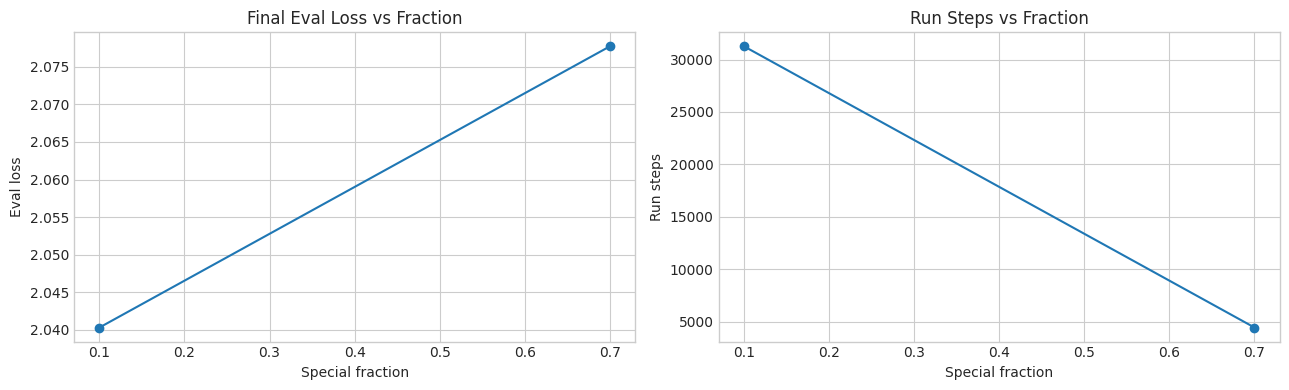

In [7]:
# Plot endpoint metrics by fraction
if run_summaries_df.empty:
    print("No summary data to plot.")
else:
    plot_df = run_summaries_df.sort_values("fraction").copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(plot_df["fraction"], plot_df["eval_loss"], marker="o")
    axes[0].set_title("Final Eval Loss vs Fraction")
    axes[0].set_xlabel("Special fraction")
    axes[0].set_ylabel("Eval loss")

    if "run_steps" in plot_df.columns:
        axes[1].plot(plot_df["fraction"], plot_df["run_steps"], marker="o")
        axes[1].set_ylabel("Run steps")
        axes[1].set_title("Run Steps vs Fraction")
    else:
        axes[1].plot(plot_df["fraction"], plot_df["dataset_size"], marker="o")
        axes[1].set_ylabel("Dataset size")
        axes[1].set_title("Dataset Size vs Fraction")

    axes[1].set_xlabel("Special fraction")
    plt.tight_layout()
    plt.show()

,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
3,2026-03-05T16:06:20Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-05T16:08:03Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-03-05T16:09:47Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-03-05T16:11:31Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-03-05T16:11:36Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,2026-03-05T16:39:51Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,2026-03-05T16:49:16Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,2026-03-05T16:57:40Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,2026-03-05T17:06:04Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,2026-03-05T17:06:10Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


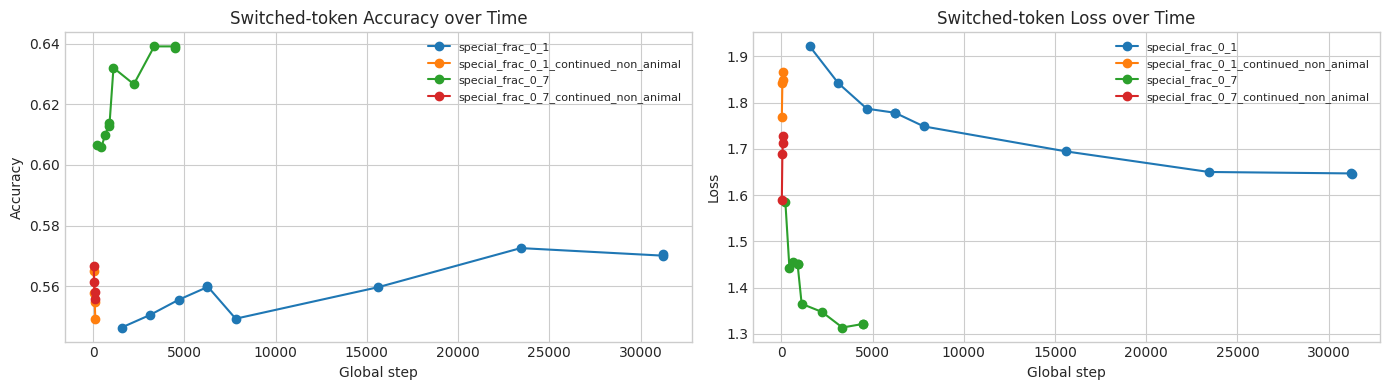

In [8]:
# Timestep switched-token metrics
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        ts["global_step"] = pd.to_numeric(ts["global_step"], errors="coerce")
        ts["switched_acc"] = pd.to_numeric(ts["switched_acc"], errors="coerce")
        ts["switched_loss"] = pd.to_numeric(ts["switched_loss"], errors="coerce")

        display(ts.sort_values(["run", "global_step"]).head(20))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for run_name, g in ts.groupby("run"):
            g = g.sort_values("global_step")
            axes[0].plot(g["global_step"], g["switched_acc"], marker="o", label=run_name)
            axes[1].plot(g["global_step"], g["switched_loss"], marker="o", label=run_name)

        axes[0].set_title("Switched-token Accuracy over Time")
        axes[0].set_xlabel("Global step")
        axes[0].set_ylabel("Accuracy")

        axes[1].set_title("Switched-token Loss over Time")
        axes[1].set_xlabel("Global step")
        axes[1].set_ylabel("Loss")

        axes[0].legend(fontsize=8)
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

In [10]:
# Compare last timestep metric per run
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        ts["global_step"] = pd.to_numeric(ts["global_step"], errors="coerce")
        last_idx = ts.groupby("run")["global_step"].idxmax()
        last_df = ts.loc[last_idx].sort_values("run").reset_index(drop=True)
        display(last_df[["run", "global_step", "switched_acc", "switched_loss", "switched_ppl"]])

,run,global_step,switched_acc,switched_loss,switched_ppl
0,special_frac_0_1,31250.0,0.570478,1.646530,5.188941
1,special_frac_0_1_continued_non_animal,120.0,0.549272,1.865181,6.457104
2,special_frac_0_7,4465.0,0.638669,1.321058,3.747383
3,special_frac_0_7_continued_non_animal,120.0,0.555925,1.727619,5.627241


,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
9,2026-03-05T16:11:49Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2026-03-05T16:11:56Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2026-03-05T16:12:04Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2026-03-05T16:12:11Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,2026-03-05T16:13:58Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2026-03-05T16:14:05Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,2026-03-05T16:14:12Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2026-03-05T16:14:19Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


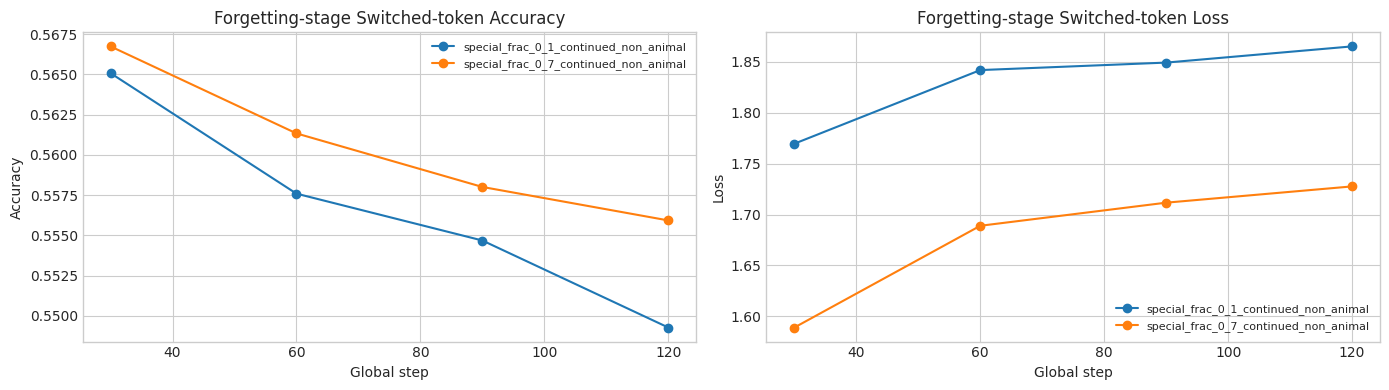

In [11]:
# Forgetting-stage switched-token metrics (continuation runs)
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        run_col = ts.get("run", pd.Series(index=ts.index, dtype=str)).astype(str)
        stage_col = ts.get("stage", pd.Series(index=ts.index, dtype=str)).astype(str).str.lower()

        forgetting_mask = (
            run_col.str.contains("continued_non_animal|forget", case=False, na=False)
            | stage_col.isin(["forgetting", "continuation", "continued_non_animal"])
        )

        forget_ts = ts[forgetting_mask].copy()
        if forget_ts.empty:
            print("No forgetting-stage timestep rows found. (Expected run names like '*continued_non_animal*' or stage='forgetting').")
        else:
            forget_ts["global_step"] = pd.to_numeric(forget_ts["global_step"], errors="coerce")
            forget_ts["switched_acc"] = pd.to_numeric(forget_ts["switched_acc"], errors="coerce")
            forget_ts["switched_loss"] = pd.to_numeric(forget_ts["switched_loss"], errors="coerce")

            display(forget_ts.sort_values(["run", "global_step"]).head(20))

            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            for run_name, g in forget_ts.groupby("run"):
                g = g.sort_values("global_step")
                axes[0].plot(g["global_step"], g["switched_acc"], marker="o", label=run_name)
                axes[1].plot(g["global_step"], g["switched_loss"], marker="o", label=run_name)

            axes[0].set_title("Forgetting-stage Switched-token Accuracy")
            axes[0].set_xlabel("Global step")
            axes[0].set_ylabel("Accuracy")

            axes[1].set_title("Forgetting-stage Switched-token Loss")
            axes[1].set_xlabel("Global step")
            axes[1].set_ylabel("Loss")

            axes[0].legend(fontsize=8)
            axes[1].legend(fontsize=8)
            plt.tight_layout()
            plt.show()

In [12]:
# Load trained models and generate sample outputs
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if run_summaries_df.empty:
    print("No run summaries found yet, so no models to load.")
else:
    # Collect model dirs from summary, then keep a small subset for quick comparison
    model_paths = []
    for col in ["final_model_path", "continued_model_path"]:
        if col in run_summaries_df.columns:
            model_paths.extend([p for p in run_summaries_df[col].dropna().astype(str).tolist() if p])

    model_paths = sorted(dict.fromkeys(model_paths))
    if not model_paths:
        print("No model paths found in run summary.")
    else:
        # Keep this small for faster notebook iteration
        MAX_MODELS = 4
        selected_model_paths = model_paths[:MAX_MODELS]

        prompts = [
            "Laura saw a lion in the garden and",
            "Max and the dog walked to the river where",
            "Tim told the rabbit that",
            "At school, Mia learned that",
        ]

        max_new_tokens = 100
        temperature = 0.8
        top_p = 0.95

        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device: {device}")
        print("Selected models:")
        for mp in selected_model_paths:
            print(" -", mp)

        for model_path_str in selected_model_paths:
            model_path = Path(model_path_str)
            if not model_path.exists():
                print(f"Skipping missing model path: {model_path}")
                continue

            print("\n" + "=" * 100)
            print(f"MODEL: {model_path}")
            print("=" * 100)

            tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

            model = AutoModelForCausalLM.from_pretrained(str(model_path)).to(device)
            model.eval()

            for i, prompt in enumerate(prompts, start=1):
                inputs = tokenizer(prompt, return_tensors="pt").to(device)
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=True,
                        temperature=temperature,
                        top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                        eos_token_id=tokenizer.eos_token_id,
                    )
                text = tokenizer.decode(out_ids[0], skip_special_tokens=True)

                print(f"\nPrompt {i}: {prompt}")
                print("Response:")
                print(text)
                print("-" * 100)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

Using device: cuda
Selected models:
 - finetune_runs_Tim/special_frac_0_1/final_model
 - finetune_runs_Tim/special_frac_0_7/final_model

MODEL: finetune_runs_Tim/special_frac_0_1/final_model


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


Prompt 1: Laura saw a lion in the garden and
Response:
Laura saw a lion in the garden and wanted to show it to her friends. She asked him to help him with the lion. Toby was very strong and he thought he would like to put the lion in the air. He had an idea. He tried to turn the lion over and closer, but the lion was too high. He was very scared and he was getting closer. He slowly climbed in to the cage and knocked out the door. He was so surprised that he could barely keep it. He had never seen the lion so much
----------------------------------------------------------------------------------------------------

Prompt 2: Max and the dog walked to the river where
Response:
Max and the dog walked to the river where they went. Max thought it was so cool and was very excited. 

The dog said, "Let's go! I can run to the river and jump!" Max was so excited! He ran up and up and up and down, feeling the water in his hand. 

Max felt a bit scared, but he kept running and jumping as fast as 

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


Prompt 1: Laura saw a lion in the garden and
Response:
Laura saw a lion in the garden and decided to fly away. She saw a boy with a wide smile and excitedly smile. She went up to the boy and said: "Look what I have!" The boy smiled and said: "That's a great idea! I am a lion!" The boy was amazed and he said: "Hello! What's your name?"

The boy said: "I'm just a lizard. It's a funny, furry monster. I am a dragon and it was very special." The boy
----------------------------------------------------------------------------------------------------

Prompt 2: Max and the dog walked to the river where
Response:
Max and the dog walked to the river where the horses were near the river. Max saw a big, green tree with a white nose. Max wanted to climb the river, but the dog ran after the cat.

Max wanted to go with the dog, but he was too scared to move. Suddenly, the dog saw a huge bird. The bird flew away, but Max was scared. He jumped and jumped out of the river.

Max and the bird started to